In [11]:
# Install required packages (run once in Colab environment)
!pip install --quiet yfinance

# Import core libraries for data processing and analysis
import pandas as pd
import numpy as np

# SQLite for structured query and data extraction (simulating real-world data workflow)
import sqlite3

# Financial data source (Yahoo Finance API)
import yfinance as yf

In [12]:
# Define stock tickers (selected for diversification across sectors)
tickers = ["AAPL", "MSFT", "TSLA"]

# Download historical stock data from Yahoo Finance
data = yf.download(tickers, start="2022-01-01", end="2025-12-31")

# Reset index to make Date a column (better for SQL and visualization)
data = data.reset_index()

# Flatten multi-level column names for easier processing
data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns]

# Preview dataset
data.head()

/tmp/ipykernel_2882/2687911002.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2025-12-31")
[*********************100%***********************]  3 of 3 completed


,Date_,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,Open_AAPL,Open_MSFT,Open_TSLA,Volume_AAPL,Volume_MSFT,Volume_TSLA
0,2022-01-03,178.103683,323.160767,399.926666,178.955022,326.298250,400.356659,173.895982,318.362830,378.679993,174.013402,323.740000,382.583344,104487900,28865100,103931400
1,2022-01-04,175.843231,317.619507,383.196655,179.013699,323.595208,402.666656,175.275678,314.829546,374.350006,178.710355,323.237993,396.516663,99310400,32674300,100248300
2,2022-01-05,171.165817,305.426788,362.706665,176.303140,314.781319,390.113342,170.891828,305.040642,360.336670,175.755162,314.578568,382.216675,94537600,40054300,80119800
3,2022-01-06,168.308517,303.013275,354.899994,171.537695,307.666411,362.666656,167.956243,300.706004,340.166656,168.993491,302.308538,359.000000,96904000,39646100,90336600
4,2022-01-07,168.474854,303.167786,342.320007,170.402574,305.542611,360.309998,167.359321,299.354525,336.666656,169.179402,303.273963,360.123322,86709100,32720000,84164700


In [13]:
# Clean column naming (remove trailing underscore if exists)
data.columns = [col.replace("Date_", "Date") for col in data.columns]

In [14]:
# Handle missing values
data = data.dropna()

# Calculate daily returns (percentage change)
for ticker in tickers:
    data[f"{ticker}_return"] = data[f"Close_{ticker}"].pct_change()

# Calculate moving averages (7-day and 30-day)
for ticker in tickers:
    data[f"{ticker}_MA7"] = data[f"Close_{ticker}"].rolling(window=7).mean()
    data[f"{ticker}_MA30"] = data[f"Close_{ticker}"].rolling(window=30).mean()

# Drop NA values created by rolling calculations
data = data.dropna()

# Preview updated dataset
data.head()

,Date,Close_AAPL,Close_MSFT,Close_TSLA,High_AAPL,High_MSFT,High_TSLA,Low_AAPL,Low_MSFT,Low_TSLA,...,Volume_TSLA,AAPL_return,MSFT_return,TSLA_return,AAPL_MA7,AAPL_MA30,MSFT_MA7,MSFT_MA30,TSLA_MA7,TSLA_MA30
29,2022-02-14,165.466019,284.786987,291.920013,166.151865,286.486065,299.626678,163.192911,281.263358,284.383331,...,67756500,0.001423,-0.000135,0.018326,168.634916,167.229338,291.693556,296.480591,301.189048,325.070997
30,2022-02-15,169.296967,290.067566,307.476654,169.453736,290.386128,307.666656,166.808320,286.736995,297.793335,...,57286200,0.023152,0.018542,0.053291,168.690905,166.935780,290.939174,295.377484,301.146663,321.989330
31,2022-02-16,169.061813,289.729034,307.796661,169.835837,291.054334,308.809998,166.612352,284.098901,300.403320,...,51294300,-0.001389,-0.001167,0.001041,168.815471,166.709733,290.824611,294.447802,301.910950,319.475997
32,2022-02-17,165.466019,281.245056,292.116669,168.434765,287.117002,306.166656,165.064303,280.538861,291.366669,...,55178400,-0.021269,-0.029282,-0.050943,167.982659,166.519740,289.000196,293.641744,299.737139,317.122997
33,2022-02-18,163.917938,278.536469,285.660004,167.092430,284.272999,295.623322,162.830377,276.969325,279.203339,...,68501700,-0.009356,-0.009631,-0.022103,166.725730,166.373387,285.871730,292.825850,296.164760,314.814997


In [15]:
# Create SQLite database (in-memory)
conn = sqlite3.connect(":memory:")

# Save dataframe into SQL table
data.to_sql("market_data", conn, index=False, if_exists="replace")

print("Data successfully loaded into SQLite database.")

Data successfully loaded into SQLite database.


In [16]:
query_1 = """
SELECT
    AVG(Close_AAPL) as avg_aapl,
    MAX(Close_AAPL) as max_aapl,
    MIN(Close_AAPL) as min_aapl,

    AVG(Close_MSFT) as avg_msft,
    AVG(Close_TSLA) as avg_tsla
FROM market_data
"""

result_1 = pd.read_sql(query_1, conn)
print("=== KPI Summary ===")
print(result_1)

=== KPI Summary ===
     avg_aapl    max_aapl    min_aapl    avg_msft    avg_tsla
0  190.459231  285.922455  123.046814  362.959212  265.008123


In [17]:
query_2 = """
SELECT
    Date,
    AAPL_return,
    MSFT_return,
    TSLA_return
FROM market_data
WHERE
    ABS(AAPL_return) > 0.03
    OR ABS(MSFT_return) > 0.03
    OR ABS(TSLA_return) > 0.03
ORDER BY Date
"""

result_2 = pd.read_sql(query_2, conn)

print("=== High Volatility Days ===")
print(result_2.head())

=== High Volatility Days ===
                  Date  AAPL_return  MSFT_return  TSLA_return
0  2022-02-15 00:00:00     0.023152     0.018542     0.053291
1  2022-02-17 00:00:00    -0.021269    -0.029282    -0.050943
2  2022-02-22 00:00:00    -0.017812    -0.000729    -0.041366
3  2022-02-23 00:00:00    -0.025864    -0.025893    -0.069979
4  2022-02-24 00:00:00     0.016680     0.051094     0.048073


In [18]:
query_3 = """
SELECT
    Date,
    AAPL_return
FROM market_data
ORDER BY AAPL_return DESC
LIMIT 5
"""

top_days = pd.read_sql(query_3, conn)

print("=== Top AAPL Gain Days ===")
print(top_days)

=== Top AAPL Gain Days ===
                  Date  AAPL_return
0  2025-04-09 00:00:00     0.153288
1  2022-11-10 00:00:00     0.088974
2  2022-10-28 00:00:00     0.075552
3  2024-06-11 00:00:00     0.072649
4  2025-05-12 00:00:00     0.063146


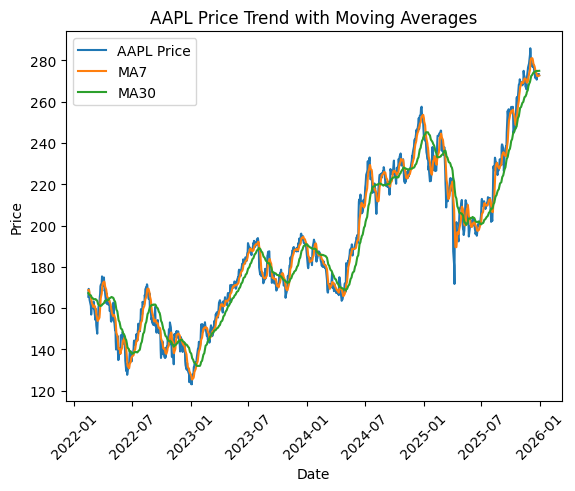

In [19]:
import matplotlib.pyplot as plt

# Plot AAPL price with moving averages
plt.figure()

plt.plot(data["Date"], data["Close_AAPL"], label="AAPL Price")
plt.plot(data["Date"], data["AAPL_MA7"], label="MA7")
plt.plot(data["Date"], data["AAPL_MA30"], label="MA30")

plt.title("AAPL Price Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.xticks(rotation=45)
plt.show()

In [20]:
# Save cleaned dataset
data.to_csv("cleaned_market_data.csv", index=False)

print("Dataset exported for Tableau.")

Dataset exported for Tableau.
